# 4. Counterfactual criticality, calibration and the compute trade

The product: rank nodes by *measured* downstream impact rather than by
intrinsic risk features, show where the two disagree, and let the simulator
settle it.

In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "2")
import sys
sys.path.insert(0, "../src")
import numpy as np, pandas as pd, torch
torch.set_num_threads(2)
import matplotlib.pyplot as plt
pd.set_option("display.width", 130)


In [2]:
T = '../results/tables/'
rank = pd.read_csv(T+'criticality_summary.csv')
rank.round(4).to_string(index=False)

'            method  spearman_full  recall@5  precision@5  jaccard@5  regret_frac@5  recall@10  precision@10  jaccard@10  regret_frac@10  recall@20  precision@20  jaccard@20  regret_frac@20  speedup_vs_simulator  method_seconds  sim_seconds  score_std  score_range  distinct_scores\n         surrogate         0.2071    0.3333       0.5333     0.2103         0.5546     0.4333        0.5167      0.2888          0.4701     0.5045        0.4250      0.3940          0.3378                 3.396          0.8179       2.6186     0.0007       0.0048          24.1667\n       tabular_gbt            NaN    0.0000       0.1000     0.0000         0.9943     0.0500        0.1667      0.0263          0.9792     0.1660        0.2583      0.3740          0.7724               600.997          0.0071       2.6186     0.0000       0.0000           1.0000\n     tabular_ridge         0.4324    0.2000       0.6667     0.1204         0.7029     0.4167        0.6167      0.2832          0.5457     0.5749       

## Where the feature score and the counterfactual disagree

Each row is a pair the two rankings order oppositely. `winner` is the
simulator's verdict — there is no arguing about it, because the counterfactual
was actually run.

In [3]:
dis = pd.read_csv(T+'disagreements.csv')
if len(dis):
    print('winner counts:'); print(dis.winner.value_counts().to_string())
    display(dis.nlargest(6,'margin')[['network','node_a','node_b','rank_a_feature','rank_b_feature','rank_a_counterfactual','rank_b_counterfactual','truth_a','truth_b','winner','margin']].round(4))
    print()
    print(dis.nlargest(1,'margin').explanation.iloc[0])
else:
    print('no disagreements found')

winner counts:
winner
counterfactual    36


,network,node_a,node_b,rank_a_feature,rank_b_feature,rank_a_counterfactual,rank_b_counterfactual,truth_a,truth_b,winner,margin
24,shift_4,0,45,1,46,12,1,0,0.743,counterfactual,0.743
25,shift_4,1,45,2,46,13,1,0,0.743,counterfactual,0.743
26,shift_4,2,45,3,46,14,1,0,0.743,counterfactual,0.743
27,shift_4,4,45,5,46,16,1,0,0.743,counterfactual,0.743
28,shift_4,5,45,6,46,17,1,0,0.743,counterfactual,0.743
29,shift_4,6,45,7,46,18,1,0,0.743,counterfactual,0.743



node 0: tier 0, 4 customers, reaches 6 demand points (0 sole-sourced), throughput 158.9, capacity slack 0.15 | node 45: tier 3, 7 customers, reaches 7 demand points (3 sole-sourced), throughput 63.5, capacity slack 0.41


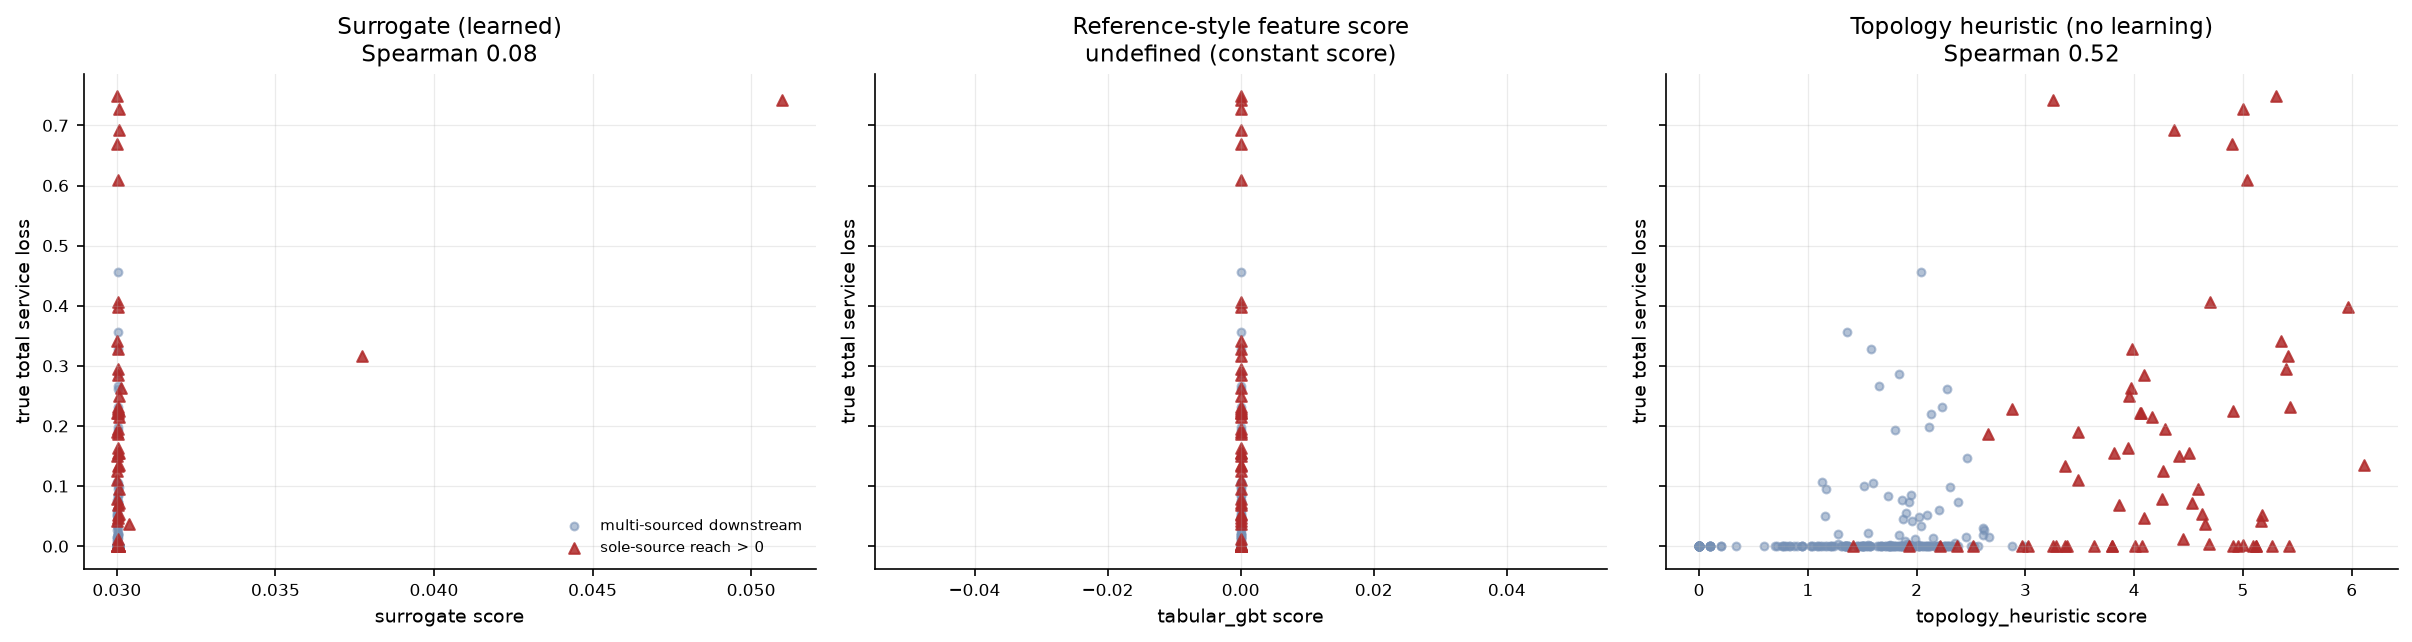

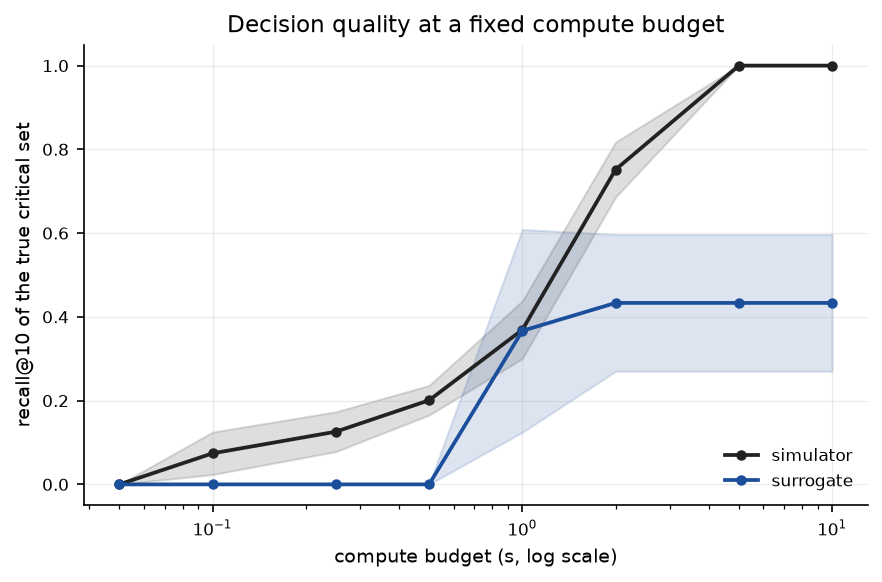

In [4]:
from IPython.display import Image, display
import os
for f in ('criticality_scatter.png','budget_curve.png'):
    if os.path.exists('../results/figures/'+f): display(Image(filename='../results/figures/'+f))

## Does the surrogate know when it does not know?

Coverage without sharpness is meaningless (a `[0,1]` interval covers
everything), so both are reported. The property that matters out of
distribution is whether error *grows with* predicted uncertainty.

In [5]:
cal = pd.read_csv(T+'calibration.csv')
g = cal[(cal.interval=='gaussian')]
g.pivot_table(index='split', columns='nominal', values=['coverage','width']).round(4)

coverage                           width                        
nominal         0.50    0.80    0.90    0.95    0.50    0.80    0.90    0.95
split                                                                       
shift_multi   0.9078  0.9381  0.9520  0.9646  0.0612  0.1022  0.1268  0.1480
shift_size    0.9609  0.9747  0.9816  0.9844  0.0497  0.0849  0.1059  0.1241
shift_topo    0.9514  0.9716  0.9798  0.9874  0.0442  0.0757  0.0946  0.1109
shift_type    0.9773  0.9848  0.9874  0.9880  0.0355  0.0623  0.0784  0.0923
test_id       0.9674  0.9831  0.9876  0.9902  0.0442  0.0757  0.0945  0.1108
train         0.9636  0.9752  0.9812  0.9857  0.0437  0.0748  0.0934  0.1096
val           0.9551  0.9694  0.9772  0.9831  0.0434  0.0745  0.0931  0.1092

In [6]:
sh = cal[cal.interval=='uncertainty_shift']
sh[['split','mean_sigma','mean_abs_error','sigma_error_spearman','error_detection_auroc','ause','mean_sigma_aleatoric','mean_sigma_epistemic']].round(4).to_string(index=False)

'      split  mean_sigma  mean_abs_error  sigma_error_spearman  error_detection_auroc   ause  mean_sigma_aleatoric  mean_sigma_epistemic\n      train      0.0513          0.0164                0.9293                 0.9915 0.0463                0.0511                0.0023\n        val      0.0512          0.0179                0.9244                 0.9913 0.0467                0.0511                0.0021\n    test_id      0.0518          0.0153                0.9406                 0.9922 0.0323                0.0517                0.0023\n shift_topo      0.0519          0.0176                0.8941                 0.9819 0.0580                0.0518                0.0024\n shift_size      0.0579          0.0186                0.9369                 0.9902 0.0504                0.0577                0.0027\n shift_type      0.0442          0.0103                0.9099                 0.9841 0.0608                0.0442                0.0010\nshift_multi      0.0676          0.0356 

## Decision quality at a fixed compute budget

The honest framing. Given N seconds, the simulator evaluates a few candidates
exactly; the surrogate screens all of them approximately. Which finds the true
top-10 more reliably?

In [7]:
bud = pd.read_csv(T+'budget_curve.csv')
bud.groupby(['budget_s','method']).recall_at_k.mean().unstack().round(3)

method,simulator,surrogate
budget_s,,
0.05,0.000,0.000
0.10,0.074,0.000
0.25,0.126,0.000
0.50,0.201,0.000
1.00,0.369,0.367
2.00,0.752,0.433
5.00,1.000,0.433
10.00,1.000,0.433


In [8]:
eff = pd.read_csv(T+'efficiency.csv')
display(eff.groupby(['component','variant'])[['median_ms','iqr_ms','per_item_ms']].median().round(4))
be = pd.read_csv(T+'break_even.csv')
be.T

median_ms    iqr_ms  per_item_ms
component                        variant                                     
simulator                        shift_size   108.4670    9.9628     108.4670
                                 shift_topo    50.3284    5.7636      50.3284
surrogate_batched_all_candidates shift_size   589.8935  105.2922       6.4119
                                 shift_topo   202.9000   20.3435       4.4109
surrogate_single                 shift_size    51.8127   30.3842      51.8127
                                 shift_topo    27.8576    5.8990      27.8576

,0
train_seconds,296.085
dataset_seconds,313.247
setup_seconds,609.332
sim_ms_per_scenario,50.3284
surrogate_ms_per_scenario,4.41088
saving_per_scenario_ms,45.9175
break_even_scenarios,13270.2
speedup_per_scenario,11.4101
ensemble_train_seconds,888.256
ensemble_members,3


The break-even row is the honest part: it charges the surrogate for **both** its
training time and the dataset generation that used the very simulator it
replaces. Below that many screened scenarios, running the simulator directly is
the better trade.